<a href="https://colab.research.google.com/github/r-karra/learn-quantum-AI/blob/main/your_first_quantum_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build and run your first quantum program

In [2]:
!uv pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

Using Python 3.12.13 environment at: /usr
Resolved 49 packages in 2.99s
Prepared 13 packages in 1.26s
Installed 13 packages in 44ms
 + ibm-cloud-sdk-core==3.24.4
 + ibm-platform-services==0.75.0
 + ibm-quantum-schemas==0.7.20260419
 + pybase64==1.4.3
 + pylatexenc==2.10
 + pyspnego==0.12.1
 + qiskit==2.4.1
 + qiskit-aer==0.17.2
 + qiskit-ibm-runtime==0.46.1
 + requests-ntlm==1.3.0
 + rustworkx==0.17.1
 + samplomatic==0.18.0
 + stevedore==5.7.0


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


In [3]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("PYthon: ", sys.version.split()[0])
print("Qiskit: ", qiskit.__version__)
print("Qiskit Aer: ", qiskit_aer.__version__)
print("Qiskit-IBM-Runtime: ", qiskit_ibm_runtime.__version__)

PYthon:  3.12.13
Qiskit:  2.4.1
Qiskit Aer:  0.17.2
Qiskit-IBM-Runtime:  0.46.1


Specific gates used to create the different Bell states. The Hadamard (H) gate and Controlled-NOT (CX) gate are fundamental for creating entanglement, but other gates like X (NOT) and Z (phase flip) are used to achieve the specific superpositions and phases of the other Bell states. Let's break down the logic for each state:

General Bell State Construction
All four Bell states start from the computational basis state $|00\rangle$. The basic sequence to create an entangled state is:

Hadamard (H) on the first qubit: This puts the first qubit into an equal superposition of $|0\rangle$ and $|1\rangle$. So, $|00\rangle \xrightarrow{H_0} \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$.
Controlled-NOT (CX) with the first qubit as control and second as target: This gate entangles the qubits. If the control qubit is $|0\rangle$, nothing happens to the target. If the control is $|1\rangle$, the target qubit is flipped. So, $\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \xrightarrow{CX_{01}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$. This is the $Φ^+$ (phi-plus) Bell state.
Logic for specific Bell states:
$Φ^-$ (phi-minus): $\frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$
To get a minus sign between the terms, we need to manipulate the phase of one of the branches before entanglement. Your code bell.x(0); bell.h(0); bell.cx(0, 1) achieves this:

Start with $|00\rangle$.
X gate on qubit 0 ($X_0$): Flips the state of qubit 0 from $|0\rangle$ to $|1\rangle$. So, $|00\rangle \xrightarrow{X_0} |10\rangle$.
Hadamard (H) on qubit 0 ($H_0$): Puts the first qubit in the $|-\rangle$ state. So, $|10\rangle \xrightarrow{H_0} \frac{1}{\sqrt{2}}(|00\rangle - |10\rangle)$.
Controlled-NOT (CX) with q0 as control, q1 as target ($CX_{01}$): Entangles the qubits. When the control is $|0\rangle$, the target remains $|0\rangle$. When the control is $|1\rangle$, the target flips to $|1\rangle$. Thus, $\frac{1}{\sqrt{2}}(|00\rangle - |10\rangle) \xrightarrow{CX_{01}} \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$.
Logic: The initial $X_0$ gate effectively prepares the first qubit in the $|1\rangle$ state, so when the Hadamard is applied, it creates the $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$ state, which then leads to the minus sign in the entangled state.
$Ψ^+$ (psi-plus): $\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$
This state involves a superposition of the qubits being in different states (one is 0, the other is 1). Your code in cell HjfG0PtpSw72 uses the following sequence: bell.x(1); bell.h(0); bell.cx(0, 1):

Start with $|00\rangle$.
X gate on qubit 1 ($X_1$): Flips the state of qubit 1 to $|1\rangle$. So, $|00\rangle \xrightarrow{X_1} |01\rangle$.
Hadamard (H) on qubit 0 ($H_0$): Puts the first qubit into superposition. So, $|01\rangle \xrightarrow{H_0} \frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)$.
Controlled-NOT (CX) with q0 as control, q1 as target ($CX_{01}$): Entangles the qubits. When the control is $|0\rangle$, the target remains $|1\rangle$. When the control is $|1\rangle$, the target flips to $|0\rangle$. Thus, $\frac{1}{\sqrt{2}}(|01\rangle + |11\rangle) \xrightarrow{CX_{01}} \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$.
Logic: By applying $X_1$ first, you effectively change the initial basis for the CNOT operation. Instead of starting with two $|0\rangle$ states, you start with $|01\rangle$. The CNOT then creates an entanglement between $|01\rangle$ and $|10\rangle$ (where the second qubit has flipped).
$Ψ^-$ (psi-minus): $\frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$
This state is similar to $Ψ^+$ but with a relative minus phase. Your code in cell AnYy4PQ3VXXI uses: bell.x(1); bell.h(0); bell.cx(0, 1); bell.z(0):

Start with $|00\rangle$.
X gate on qubit 1 ($X_1$): Flips qubit 1 to $|1\rangle$. So, $|00\rangle \xrightarrow{X_1} |01\rangle$.
Hadamard (H) on qubit 0 ($H_0$): Puts the first qubit into superposition. So, $|01\rangle \xrightarrow{H_0} \frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)$.
Controlled-NOT (CX) with q0 as control, q1 as target ($CX_{01}$): Entangles the qubits. This results in the $Ψ^+$ state: $\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$.
Z gate on qubit 0 ($Z_0$): The Z gate applies a phase flip: it leaves $|0\rangle$ unchanged but flips the sign of $|1\rangle$ to $-|1\rangle$. Applying $Z_0$ to the $Ψ^+$ state: $\frac{1}{\sqrt{2}}(Z_0|01\rangle + Z_0|10\rangle) = \frac{1}{\sqrt{2}}(|01\rangle + (-1)|10\rangle) = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$.
Logic: You first create the $Ψ^+$ state. Then, to introduce the relative minus sign, you apply a $Z_0$ gate. Since qubit 0 is in a superposition ($|0\rangle$ in the $|01\rangle$ term and $|1\rangle$ in the $|10\rangle$ term), the $Z_0$ gate only affects the $|10\rangle$ component by flipping the phase of its $|1\rangle_0$ part, thus creating the desired $Ψ^-$ state. (Note: The get_bell_state function's psi_minus definition also includes an additional qc.z(1) which adds a global phase of -1 to the result, but does not change the physical state or measurement outcomes.)

Bell State phi_plus: [0.70710678+0.j,0.        +0.j,0.        +0.j,0.70710678+0.j]


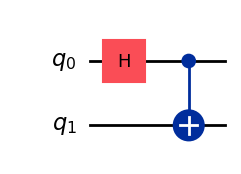

Bell State phi_minus: [ 0.70710678+0.j, 0.        +0.j, 0.        +0.j,-0.70710678+0.j]


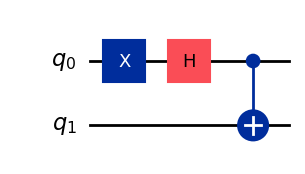

Bell State psi_plus: [0.        +0.j,0.70710678+0.j,0.70710678+0.j,0.        +0.j]


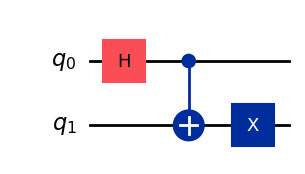

Bell State psi_minus: [ 0.        +0.j,-0.70710678+0.j,-0.70710678+0.j, 0.        +0.j]


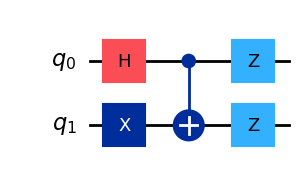

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def get_bell_state(name):
    qc = QuantumCircuit(2)
    if name == 'phi_plus':
        qc.h(0)
        qc.cx(0, 1)
    elif name == 'phi_minus':
        qc.x(0)
        qc.h(0)
        qc.cx(0, 1)
    elif name == 'psi_plus':
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
    elif name == 'psi_minus':
        qc.x(1)
        qc.h(0)
        qc.cx(0, 1)
        qc.z(0)
        qc.z(1)
    return qc

states = ['phi_plus', 'phi_minus', 'psi_plus', 'psi_minus']

for s in states:
    qc = get_bell_state(s)
    sv = Statevector.from_instruction(qc)
    print(f"Bell State {s}: {sv.draw('text')}")
    display(qc.draw('mpl'))

# $Φ^+$  (phi-plus) Bell state)
To build the Bell state circuit, we use an
H (Hadamard) gate to put the first qubit into an equal superposition. Then we apply a
CX (controlled-NOT) gate, which entangles the two states together. The two qubits are now correlated in a way that has no classical equivalent.


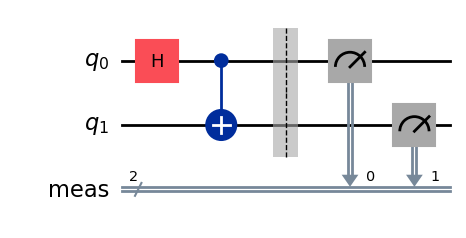

In [ ]:
# ---build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all() # creates a classical regisster named "meas"
bell.draw("mpl")

# Helper function for running circuits
Now let's define a helper function that handles the process of running a quantum circuit and retrieving measurement results. This function takes care of transpiling the circuit to match the backend's instruction set, running it through a `Sampler` primitive, and extracting the counts from the results.

In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

#Access your secret keys in Python via:

In [ ]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Retrieve the secret token
ibmq_token = userdata.get('IBMQ_TOKEN')

# Initialize the Qiskit Runtime Service
# Note: The channel name is now 'ibm_quantum_platform'
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=ibmq_token)

print("IBMQ_TOKEN loaded and service initialized successfully.")

qiskit_runtime_service._discover_account:WARNING:2026-05-03 18:48:54,316: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-03 18:48:57,580: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


IBMQ_TOKEN loaded and service initialized successfully.


#Run on a QPU and visualize results


In [ ]:
# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# # backend = service.backend("ibm_fez")
# print(backend.name)

#Run on a AerSimulator

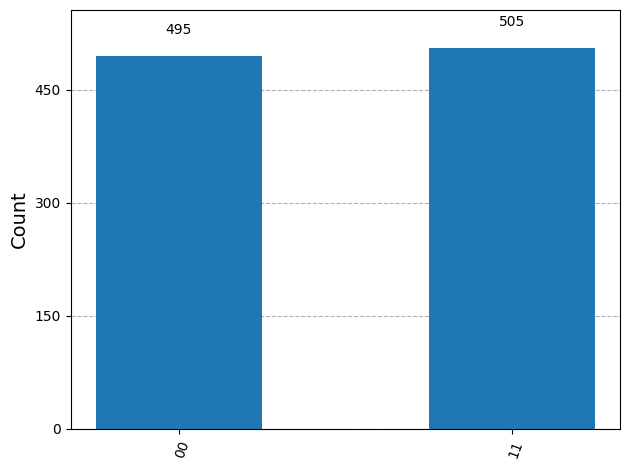

In [ ]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

Statevector:  Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


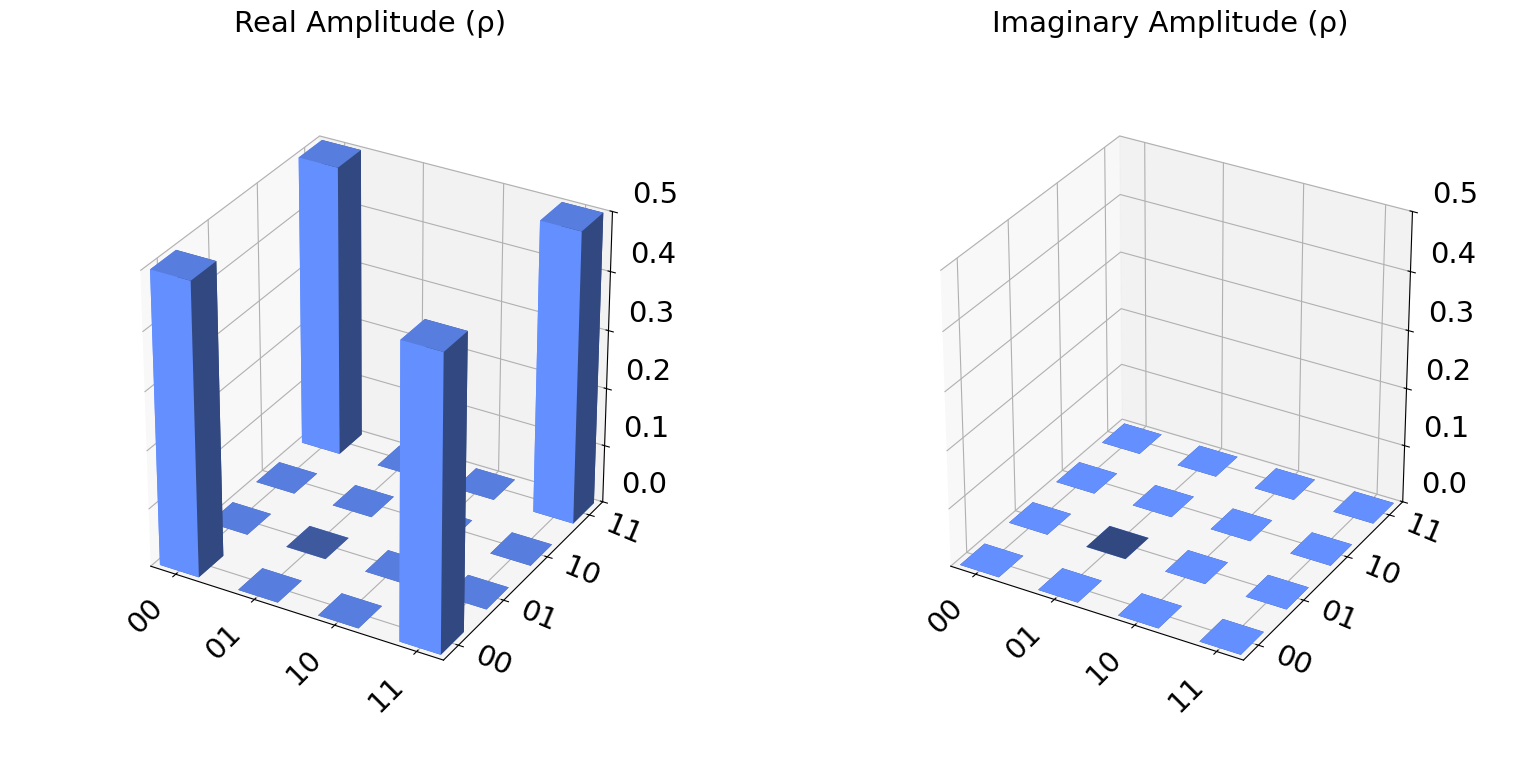

In [ ]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city

# Create the circuit without measurement to see the phase
bell_no_meas = QuantumCircuit(2)
bell_no_meas.h(0)
bell_no_meas.cx(0, 1)

# Get the state vector
state = Statevector.from_instruction(bell_no_meas)

print("Statevector: ", state)

# Visualize the state to see the phase (the plus sign reflects in the complex components)
plot_state_city(state)


# $Φ^-$  (phi-minus) Bell state)

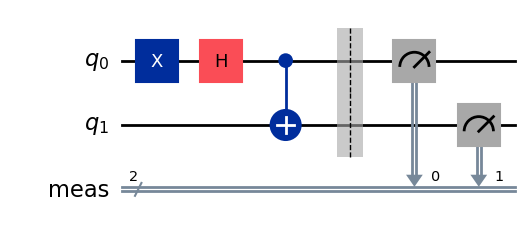

In [ ]:
bell = QuantumCircuit(2)
# Apply X and H to the first qubit to start in the |-> state
bell.x(0)
bell.h(0)
# Entangle with the second qubit
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

# Helper function for running circuits

In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)

  sampler = Sampler(mode=backend)

  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()
  return result[0].data.meas.get_counts()

#Run on a Simulator

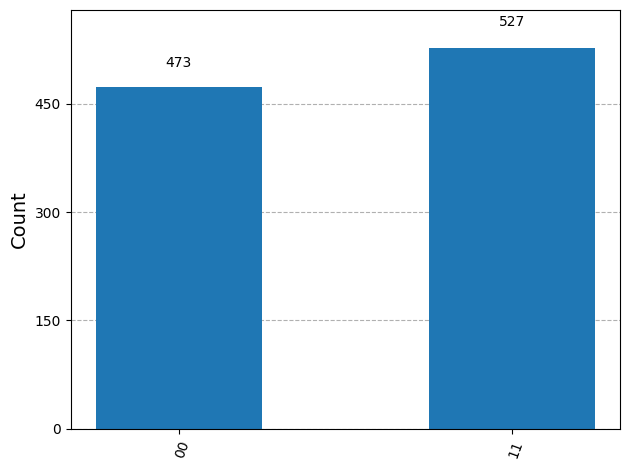

In [ ]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots = 1000)
plot_histogram(counts)

Statevector: Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))


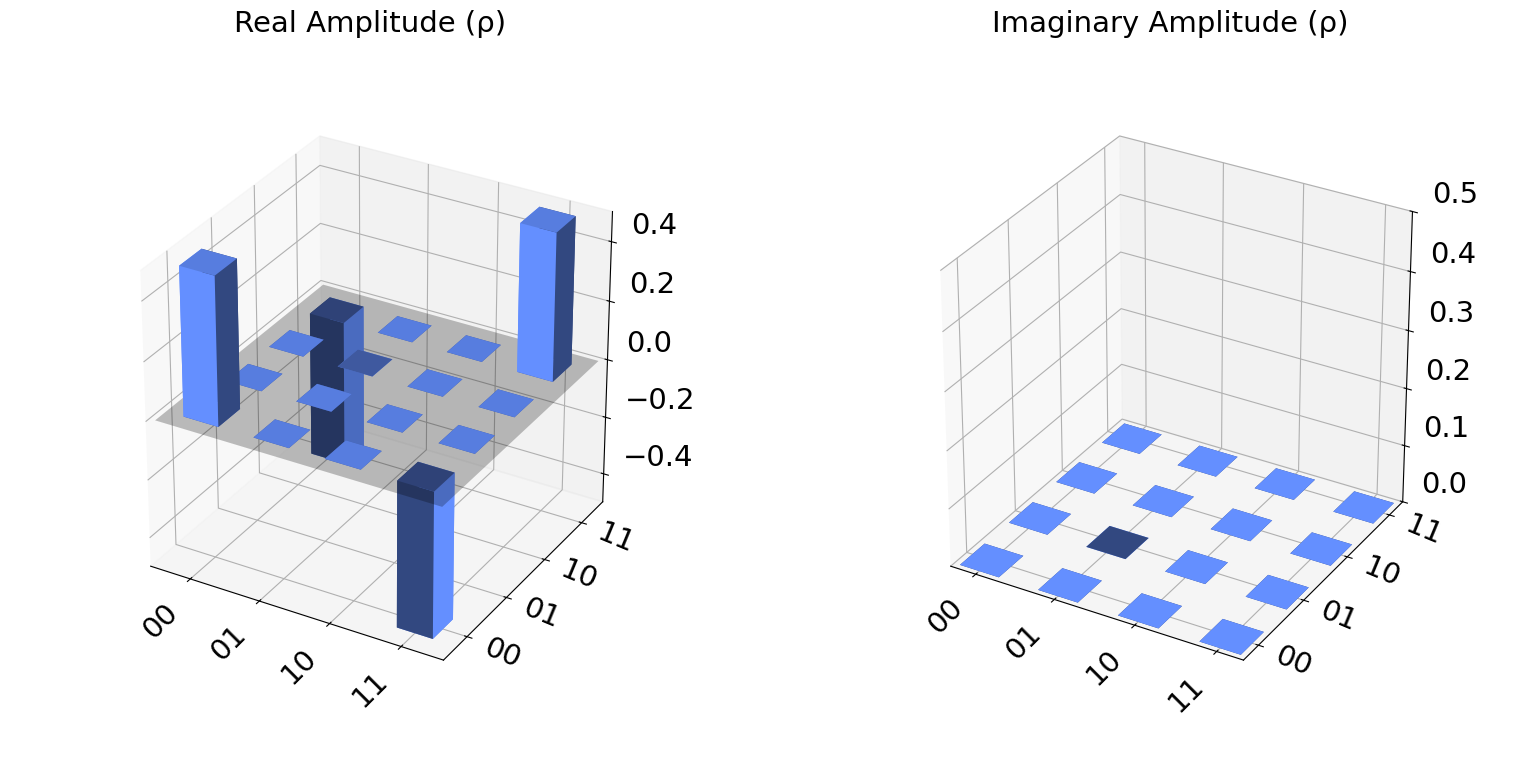

In [ ]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city

# Create the circuit without measurement to see the phase
bell_no_meas = QuantumCircuit(2)
bell_no_meas.x(0)
bell_no_meas.h(0)
bell_no_meas.cx(0, 1)

# Get the statevector
state = Statevector.from_instruction(bell_no_meas)

print("Statevector:", state)
# Visualize the state to see the phase (the minus sign reflects in the complex components)
plot_state_city(state)

# $Ψ^+$ Bell State: psi_plus:

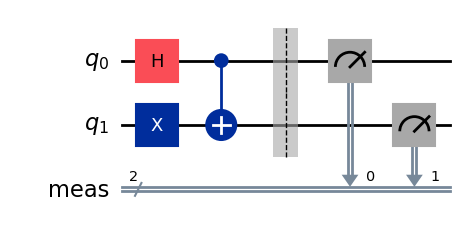

In [ ]:
# Initialize a quantum circuit with 2 qubits
bell = QuantumCircuit(2)

# Apply X gate to qubit 1 to flip it to |1>
bell.x(1)

# Apply Hadamard gate to qubit 0 to create superposition
bell.h(0)

# Apply CNOT gate with q0 as control and q1 as target to entangle them
bell.cx(0, 1)

# Measure all qubits and store results in classical bits
bell.measure_all()

# Draw the circuit using the Matplotlib backend
bell.draw('mpl')

In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)

  sampler = Sampler(mode=backend)
  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()
  return result[0].data.meas.get_counts()

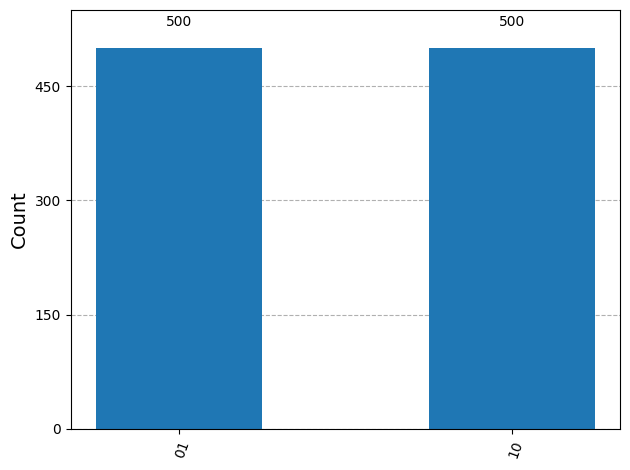

In [ ]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

Statevector:  Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))


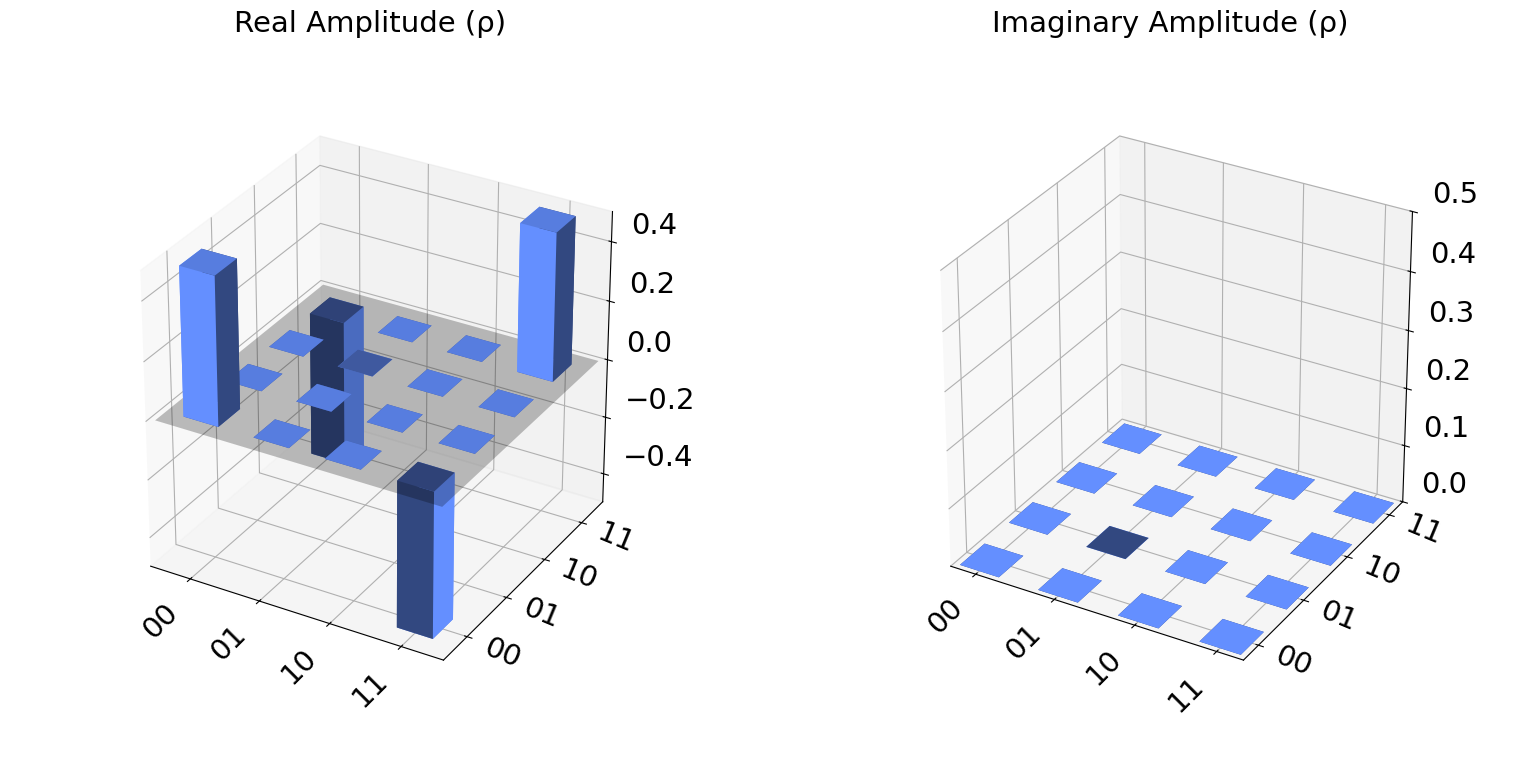

In [ ]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city

bell_without_meas = QuantumCircuit(2)
bell_without_meas.x(0)
bell_without_meas.h(0)
bell_without_meas.cx(0, 1)

state = Statevector.from_instruction(bell_without_meas)

print("Statevector: ", state)
# Visualize the state to see the phase (the minus sign reflects in the complex components)
plot_state_city(state)


# $Ψ^-$ Bell State: psi_minus:

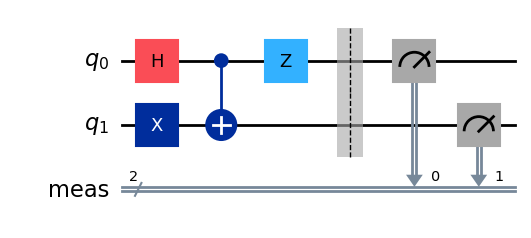

In [ ]:
bell = QuantumCircuit(2)
# Start in |01> state by flipping qubit 1
bell.x(1)
# Put qubit 0 into an equal superposition of |0> and |1>
bell.h(0)
# Entangle qubits: if q0 is 1, flip q1. Result is (|01> + |10>) / sqrt(2)
bell.cx(0, 1)
# Apply Z gate to qubit 0 to flip the sign of the |1> component
# This results in (|01> - |10>) / sqrt(2)
bell.z(0)
# Map quantum results to classical bits
bell.measure_all()
# Visualize the circuit
bell.draw("mpl")

In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)

  sampler = Sampler(mode=backend)
  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()
  return result[0].data.meas.get_counts()

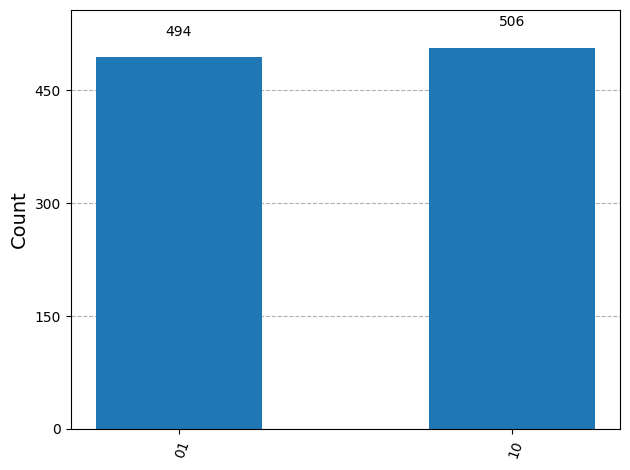

In [ ]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

Statevector:  Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


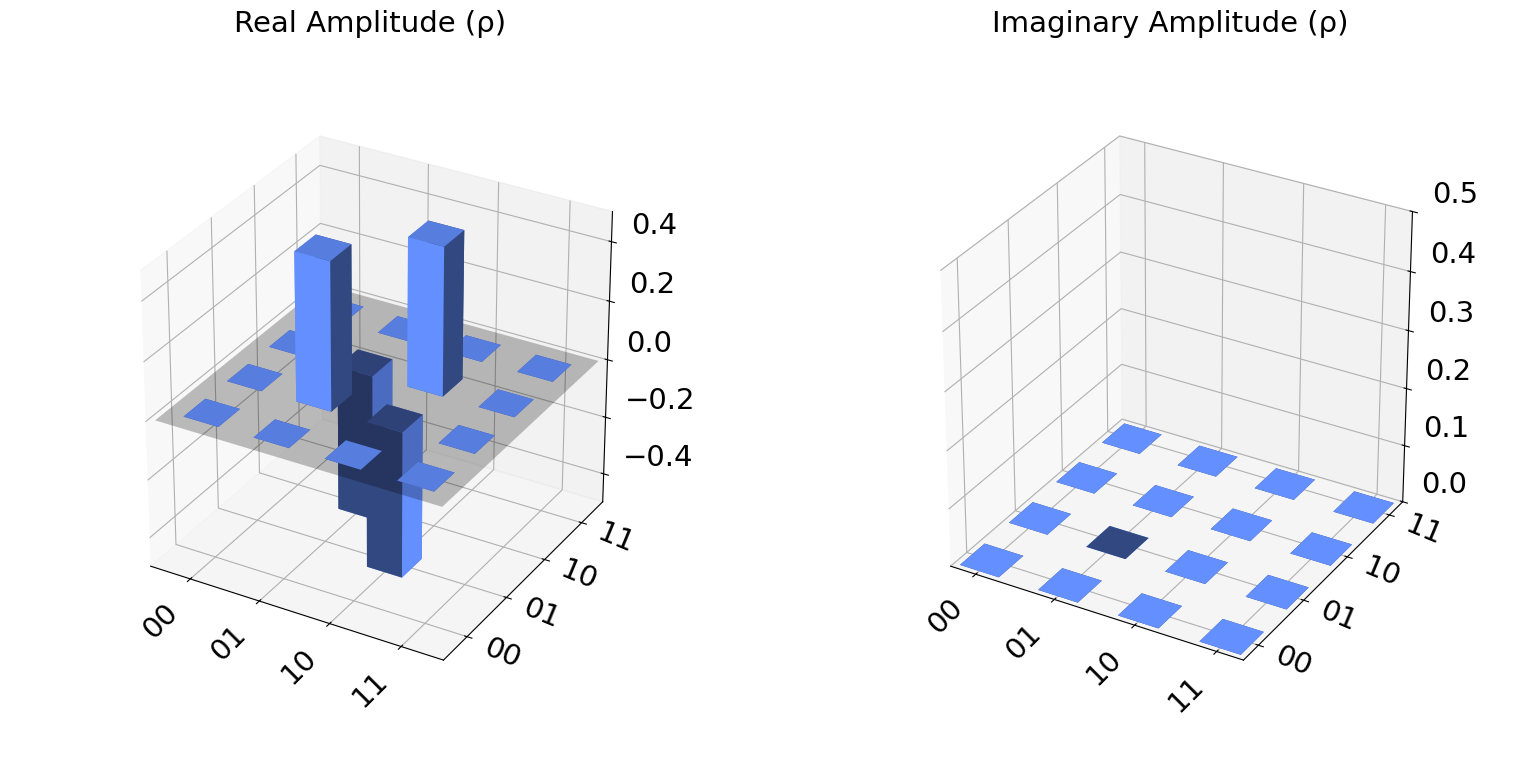

In [ ]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city

bell_no_meas= QuantumCircuit(2)
bell_no_meas.x(1)
bell_no_meas.h(0)
bell_no_meas.cx(0, 1)
bell_no_meas.z(0)

state = Statevector.from_instruction(bell_no_meas)

print("Statevector: ", state)
plot_state_city(state)

# Your first quantum experiment
## Experiment1: Use `Sampler` to measure the state
$|\Psi\rangle= \frac{1}{\sqrt{2}}(|10\rangle-|01\rangle)$

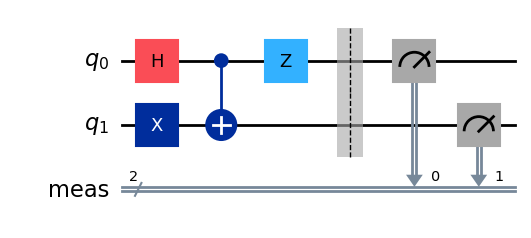

In [4]:
# Import Qiskit primitives
from qiskit import QuantumCircuit

#Make state
qc = QuantumCircuit(2)
qc.x(1)
qc.h(0)
qc.cx(0, 1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

In [13]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from google.colab import userdata

ibmq_token = userdata.get('IBMQ_TOKEN')
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=ibmq_token)
backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-05-04 10:20:28,087: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-04 10:20:30,358: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-04 10:20:30,359: Using instance: open-instance, plan: open


ibm_fez


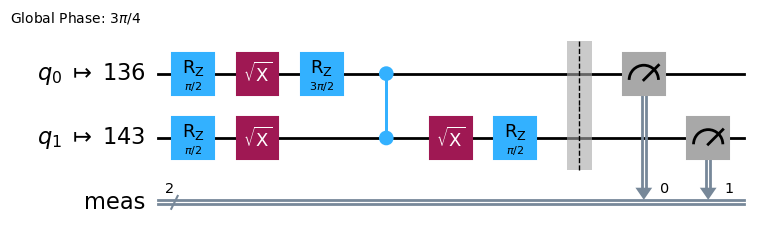

In [14]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Use the 'backend' instance directly, which is an AerSimulator object.
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

## Execute

In [16]:
#Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sammpler
sampler = Sampler(mode=backend)

In [18]:
job = sampler.run([qc_isa], shots=100)
res = job.result()
counts = res[0].data.meas.get_counts()

counts:  {'01': 45, '10': 55}


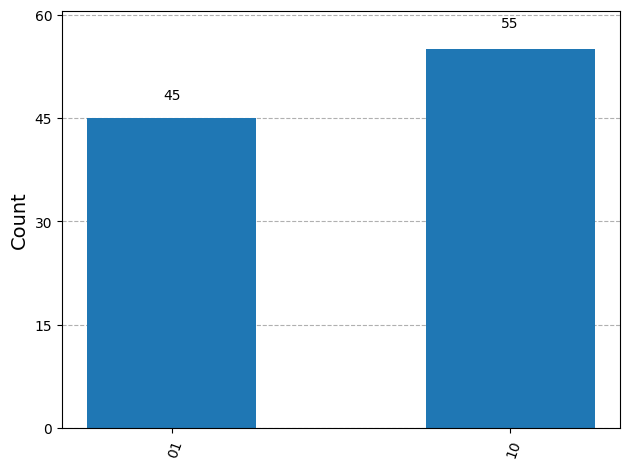

In [19]:
from qiskit.visualization import plot_histogram

print("counts: ", counts)
plot_histogram(counts)

# Experiment2: Use `Estimator` to measure the energy

## map

# Experiment 2: Use `Estimator` to measure the energy

1. Bell state: $(|10> - |01>) / sqrt(2)$

`Energy = -1.0234554025611193`

2. Bell state: $(|00> + |11>) / sqrt(2)$

Energy = `0.977872682359402`

3. Bell state: $(|00> - |11>) / sqrt(2)$

Energy = `0.9632493822335887`

4. Bell state: $(|10> + |01>) / sqrt(2)$

Energy = `-1.04762157152494`

In [32]:
# Import Qiskit Primitives

from qiskit.quantum_info import SparsePauliOp

# parameters
J = 1.0 # antiferromagnetic coupling (J<0)
hx = -0.5 # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)

obs = SparsePauliOp.from_list([
    ("ZZ", J),
     ("XI", hx),
      ("IX", hx)
])
# Make a Bell state: (|10> + |01>) / sqrt(2)
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)

# # Make a Bell state: (|10> - |01>) / sqrt(2)
# qc = QuantumCircuit(2)
# qc.h(0)
# qc.cx(0, 1)
# qc.x(1)
# qc.z(0)

# # Make a Bell state: (|00> + |11>) / sqrt(2)
# qc = QuantumCircuit(2)
# qc.h(0)
# qc.cx(0, 1)

# # Make a Bell state: (|00> - |11>) / sqrt(2)
# qc = QuantumCircuit(2)
# qc.h(0)
# qc.cx(0, 1)
# qc.z(0)


## Optimize

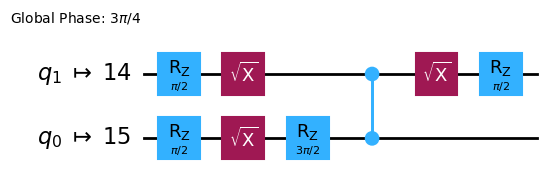

In [24]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target= target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout= qc_isa.layout)

qc_isa.draw("mpl")

## Execute

In [26]:
backend = service.backend("ibm_fez")
print(backend)

qiskit_runtime_service.backends:WARNING:2026-05-04 11:04:55,318: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


In [25]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [30]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run(
    pubs=pubs
)

res = job.result()

In [31]:
print(res[0].data.evs)

-1.0002292195829894
